<a href="https://colab.research.google.com/github/NoaTal1996/Backbone-Graph/blob/main/code/Key_Authors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports and Load Data

In [82]:
import pickle
import re
import numpy as np
import pandas as pd
from collections import defaultdict
from sklearn.feature_extraction.text import TfidfTransformer
import pprint

In [83]:
# Connect to Goole Drive to use the data.
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [84]:
# Load Data
output_dir = "/content/drive/Shareddrives/KeyBoostAuthor/data/"
# output_dir = "/dt/puzis/cnalab/KeyAuthors/"

with open(output_dir + '/israel_and_the_region.pkl', 'rb') as f:
    df = pickle.load(f)

# Print df
df.head()

,c_claim_id,c_post_id,url,author,content,date,title,description,url_right,verdict_date,keywords,domain,verdict,category,sub_category
0,007677fd-d100-3f20-936e-3dea041cfb1d,00ef3764-f159-3166-b3e3-8b1147aed472,https://twitter.com/karmel80/status/3367449316...,karmel80,"RT @ hrw: # Uganda: 2 newspapers, 2 radio stat...",2013-05-21 10:27:02,2 French journalists killed in Mali officials say,DAKAR Senegal AP Gunmen abducted and killed t...,https://www.timesofisrael.com/2-french-journal...,2013-11-03 00:36:00,Israel & the Region||Mali||France||al-Qaeda||F...,part6,1,israel-and-the-region,None
1,007677fd-d100-3f20-936e-3dea041cfb1d,01062bf4-590c-306d-b194-809d4c12b8b0,https://twitter.com/MynameRillo/status/3967710...,MynameRillo,Officials: 2 French journalists killed in Mali...,2013-11-03 00:49:32,2 French journalists killed in Mali officials say,DAKAR Senegal AP Gunmen abducted and killed t...,https://www.timesofisrael.com/2-french-journal...,2013-11-03 00:36:00,Israel & the Region||Mali||France||al-Qaeda||F...,part6,1,israel-and-the-region,None
2,007677fd-d100-3f20-936e-3dea041cfb1d,0153a78a-de08-35ea-b9e2-d717e9b34ae0,https://twitter.com/JakobDrud/status/290556648...,JakobDrud,DR (Danish Radio) tells the story of state-own...,2013-01-13 22:31:18,2 French journalists killed in Mali officials say,DAKAR Senegal AP Gunmen abducted and killed t...,https://www.timesofisrael.com/2-french-journal...,2013-11-03 00:36:00,Israel & the Region||Mali||France||al-Qaeda||F...,part6,1,israel-and-the-region,None
3,007677fd-d100-3f20-936e-3dea041cfb1d,02803736-bdab-3ff9-b5f6-933492f3b732,https://twitter.com/uk_radio/status/3499458660...,uk_radio,"Newspapers: Journalist / Regional Journalist, ...",2013-06-26 20:42:50,2 French journalists killed in Mali officials say,DAKAR Senegal AP Gunmen abducted and killed t...,https://www.timesofisrael.com/2-french-journal...,2013-11-03 00:36:00,Israel & the Region||Mali||France||al-Qaeda||F...,part6,1,israel-and-the-region,None
4,007677fd-d100-3f20-936e-3dea041cfb1d,02bae70c-0075-3954-8fe0-24f62d068286,https://twitter.com/DesMoinesNews/status/39672...,DesMoinesNews,[WOI] Officials: 2 French journalists killed i...,2013-11-02 21:33:56,2 French journalists killed in Mali officials say,DAKAR Senegal AP Gunmen abducted and killed t...,https://www.timesofisrael.com/2-french-journal...,2013-11-03 00:36:00,Israel & the Region||Mali||France||al-Qaeda||F...,part6,1,israel-and-the-region,None


# Data Preprocessing

In [85]:
# Encode 'title' categories as numeric codes in 'topic' column
df['topic'] = df['title'].astype('category').cat.codes
df.topic.value_counts()

,count
topic,
123,2640
924,2522
142,2514
297,2504
107,2498
...,...
409,49
533,45
111,38


In [86]:
df = df[['c_post_id', 'title', 'content', 'date', 'topic' , 'author']]
df.head()

,c_post_id,title,content,date,topic,author
0,00ef3764-f159-3166-b3e3-8b1147aed472,2 French journalists killed in Mali officials say,"RT @ hrw: # Uganda: 2 newspapers, 2 radio stat...",2013-05-21 10:27:02,2,karmel80
1,01062bf4-590c-306d-b194-809d4c12b8b0,2 French journalists killed in Mali officials say,Officials: 2 French journalists killed in Mali...,2013-11-03 00:49:32,2,MynameRillo
2,0153a78a-de08-35ea-b9e2-d717e9b34ae0,2 French journalists killed in Mali officials say,DR (Danish Radio) tells the story of state-own...,2013-01-13 22:31:18,2,JakobDrud
3,02803736-bdab-3ff9-b5f6-933492f3b732,2 French journalists killed in Mali officials say,"Newspapers: Journalist / Regional Journalist, ...",2013-06-26 20:42:50,2,uk_radio
4,02bae70c-0075-3954-8fe0-24f62d068286,2 French journalists killed in Mali officials say,[WOI] Officials: 2 French journalists killed i...,2013-11-02 21:33:56,2,DesMoinesNews


# Extracting Key Entity

In [87]:
# Extracting hashtags from a text and remove spaces.
def extract_hashtags(text):
    # Find all hashtag
    raw_hashtags = re.findall(r'#\s*\w+', text)
    # Remove spaces
    cleaned_hashtags = [re.sub(r'\s+', '', hashtag) for hashtag in raw_hashtags]
    return cleaned_hashtags

def extract_urls(text):
    url_pattern = r'https?://\S+'
    return re.findall(url_pattern, text)

def extract_user_mentions(text):
    mention_pattern = r'@\w+'
    return re.findall(mention_pattern, text)


# Apply the extract_hashtags function to the content of each related post
df['hashtags'] = df['content'].apply(extract_hashtags)
# df['extracted_urls'] = df['content'].apply(extract_urls)
df['user_mentions'] = df['content'].apply(extract_user_mentions)
df['author'] = df['author'].apply(lambda s: s if isinstance(s, list) else [s]) # Wraps inside a list.

df.head()


,c_post_id,title,content,date,topic,author,hashtags,user_mentions
0,00ef3764-f159-3166-b3e3-8b1147aed472,2 French journalists killed in Mali officials say,"RT @ hrw: # Uganda: 2 newspapers, 2 radio stat...",2013-05-21 10:27:02,2,[karmel80],[#Uganda],[]
1,01062bf4-590c-306d-b194-809d4c12b8b0,2 French journalists killed in Mali officials say,Officials: 2 French journalists killed in Mali...,2013-11-03 00:49:32,2,[MynameRillo],[],[]
2,0153a78a-de08-35ea-b9e2-d717e9b34ae0,2 French journalists killed in Mali officials say,DR (Danish Radio) tells the story of state-own...,2013-01-13 22:31:18,2,[JakobDrud],[],[]
3,02803736-bdab-3ff9-b5f6-933492f3b732,2 French journalists killed in Mali officials say,"Newspapers: Journalist / Regional Journalist, ...",2013-06-26 20:42:50,2,[uk_radio],[],[]
4,02bae70c-0075-3954-8fe0-24f62d068286,2 French journalists killed in Mali officials say,[WOI] Officials: 2 French journalists killed i...,2013-11-02 21:33:56,2,[DesMoinesNews],[],[]


# TF_IDF

## Calculating entities TF-IDF score

### Calculating TF
We will use the tf-idf score to give the autore hogiher score ate key autor score if she\he uses enteties with high tf-idf score macht to the topic.

In [88]:
def compute_tf_entity_by_topic(df, topic_col_name, entity_col_name):
    """
    Computes normalized term frequency of entities per topic.
    Args:
        df (DataFrame): Input DataFrame.
        topic_col_name (str): Column name with topic IDs.
        entity_col_name (str): Column name with lists of entities.
    Returns:
        dict: {topic: {entity: normalized_frequency}}
    """
    tf = defaultdict(lambda: defaultdict(int))

    # Count entity instances in the topic
    for _, row in df.iterrows():
        topic = row[topic_col_name] #the numeric uniq value of the topic.
        entities = row[entity_col_name]
        for entity in entities:
            tf[topic][entity] += 1

    # Normalize counts by total number of entities in each topic
    for topic in tf:
        total = sum(tf[topic].values())
        if total > 0:
            for entity in tf[topic]:
                tf[topic][entity] /= total

    return tf
'''
Idea 1: Use `lowercase()` or remove-spaces on entities as a form of stemming suitable for social media.
Idea 2: Use a logarithmic formula to handle big data.
'''

tf_hashtags = compute_tf_entity_by_topic(df, topic_col_name='topic', entity_col_name='hashtags')
# tf_urls = compute_tf_entity_by_topic(df, topic_col_name='topic', entity_col_name='extracted_urls')
tf_mentions = compute_tf_entity_by_topic(df, topic_col_name='topic', entity_col_name='user_mentions')
tf_author = compute_tf_entity_by_topic(df, topic_col_name='topic', entity_col_name='author')

# pprint.pprint(tf_hashtags)

### Calculating IDF


In [89]:
# Calculate DF (document frequency)

def compute_document_frequency(tf_dict):
    """
    Counts how many topics each entity appears in.
    Args:
        tf_dict (dict): {topic: {entity: tf_value}}
    Returns:
        dict: {entity: document_frequency}
    """
    df_dict = defaultdict(int)
    for topic, entities_dict in tf_dict.items():
        for entity in entities_dict:
            df_dict[entity] += 1
    return df_dict

df_hashtags = compute_document_frequency(tf_hashtags)
# df_urls = compute_document_frequency(tf_urls)
df_mentions = compute_document_frequency(tf_mentions)
df_author = compute_document_frequency(tf_author)

In [90]:
# Calculate IDF (document frequency)
def compute_idf(tf_dict, df_dict):
    """
    Computes IDF for each entity.
    Args:
        tf_dict (dict): {topic: {entity: tf}}.
        df_dict (dict): {entity: document frequency}.
    Returns:
        dict: {entity: idf score}.
    """
    num_of_topics = len(tf_dict)
    idf_dict = {entity: np.log(num_of_topics / (1 + df_dict[entity])) for entity in df_dict}
    return idf_dict

idf_hashtags = compute_idf(tf_hashtags, df_hashtags)
# idf_urls = compute_idf(tf_urls, df_urls)
idf_mentions = compute_idf(tf_mentions, df_mentions)
idf_author = compute_idf(df_author, df_author)

### Calculating TF * IDF


In [97]:
def compute_entity_tfidf_scores(entity_tf_dict, entity_idf_dict):
    """
    Computes TF-IDF scores per entity per topic.
    Args:
        entity_tf_dict (dict): {topic: {entity: tf_value}}
        entity_idf_dict (dict): {entity: idf_value}
    Returns:
        dict: {topic: {entity: tfidf_score}}
    """
    entity_tfidf_dict = defaultdict(lambda: defaultdict(float))
    for topic, entity_tf_counts_dict in entity_tf_dict.items():
        for entity, tf in entity_tf_counts_dict.items():
            idf = entity_idf_dict.get(entity, 0.0)
            entity_tfidf_dict[topic][entity] = tf * idf
    return entity_tfidf_dict

hashtags_tfidf_dict = compute_entity_tfidf_scores(tf_hashtags, idf_hashtags)
# urls_tfidf_dict = compute_entity_tfidf_scores(tf_urls, idf_urls)
mention_tfidf_dict = compute_entity_tfidf_scores(tf_mentions, idf_mentions)

# dict: {entity_type: {topic: {entity: tfidf_score}}}
all_types_entities_tfidf_dict = {
    'hashtag_scores': hashtags_tfidf_dict,
    # 'url_scores' : urls_tfidf_dict,
    'mention_scores': mention_tfidf_dict,
}

## Calculating Posts TF-IDF Score

In [96]:
def compute_post_entities_tfidf_scores(row, entity_tfidf_dict, entity_type, topic_col_name='topic'):
    """
    Calculate the total TF-IDF score for one entity type in a post's topic.
    Args:
        row (pd.Series): A row from the DataFrame.
        entity_tfidf_dict (dict): {topic: {entity: tfidf_score}}.
        entity_type (str): The entity column in the row (e.g., 'hashtags', 'mentions').
        topic_col_name (str): Name of the topic column.
    Returns:
        float: Total TF-IDF score for that entity type in the post.
    """
    topic = row[topic_col_name]
    entities = row.get(entity_type, [])
    entities_scores = [entity_tfidf_dict[topic].get(entity, 0) for entity in entities]
    return entities_scores


df['hashtag_scores'] = df.apply(compute_post_entities_tfidf_scores, axis=1, args=(hashtags_tfidf_dict, 'hashtags'))
df['mention_scores'] = df.apply(compute_post_entities_tfidf_scores, axis=1, args=(mention_tfidf_dict, 'mentions'))
# df['url_scores']     = df.apply(compute_post_entities_tfidf_scores, axis=1, args=(urls_tfidf_dict, 'urls'))

df.head()

,c_post_id,title,content,date,topic,author,hashtags,user_mentions,hashtag_scores,mention_scores
0,00ef3764-f159-3166-b3e3-8b1147aed472,2 French journalists killed in Mali officials say,"RT @ hrw: # Uganda: 2 newspapers, 2 radio stat...",2013-05-21 10:27:02,2,[karmel80],[#Uganda],[],[0.07282823658128308],[]
1,01062bf4-590c-306d-b194-809d4c12b8b0,2 French journalists killed in Mali officials say,Officials: 2 French journalists killed in Mali...,2013-11-03 00:49:32,2,[MynameRillo],[],[],[],[]
2,0153a78a-de08-35ea-b9e2-d717e9b34ae0,2 French journalists killed in Mali officials say,DR (Danish Radio) tells the story of state-own...,2013-01-13 22:31:18,2,[JakobDrud],[],[],[],[]
3,02803736-bdab-3ff9-b5f6-933492f3b732,2 French journalists killed in Mali officials say,"Newspapers: Journalist / Regional Journalist, ...",2013-06-26 20:42:50,2,[uk_radio],[],[],[],[]
4,02bae70c-0075-3954-8fe0-24f62d068286,2 French journalists killed in Mali officials say,[WOI] Officials: 2 French journalists killed i...,2013-11-02 21:33:56,2,[DesMoinesNews],[],[],[],[]


In [98]:
def compute_post_tfidf_scores(row, all_types_entities_tfidf_dict, topic_col_name='topic'):
    """
    Sum TF-IDF scores for all entity types in a post's topic.
    Args:
        row (pd.Series): A single row from the DataFrame (used with pd.apply()).
        all_types_entities_tfidf_dict (dict): {entity_type: {topic: {entity: tfidf_score}}}.
        topic_col (str): Topic column name.
    Returns:
        float: Total TF-IDF score for the post.
    """
    topic = row[topic_col_name]
    score = 0
    # Go over all the entity types and get the suitable tf-idf dict
    for entity_type, entities_tfidf_dict in all_types_entities_tfidf_dict.items():
        topic_entities_tfidf_dict = entities_tfidf_dict.get(topic, {})
        # Sum all the TF-IDF scores
        for entity in row[entity_type]:
            score += topic_entities_tfidf_dict.get(entity, 0)
    return score

df['post_topic_tfidf'] = df.apply(compute_post_tfidf_scores, axis=1, args=(all_types_entities_tfidf_dict,))
df.head()

,c_post_id,title,content,date,topic,author,hashtags,user_mentions,hashtag_scores,mention_scores,post_topic_tfidf
0,00ef3764-f159-3166-b3e3-8b1147aed472,2 French journalists killed in Mali officials say,"RT @ hrw: # Uganda: 2 newspapers, 2 radio stat...",2013-05-21 10:27:02,2,[karmel80],[#Uganda],[],[0.07282823658128308],[],0
1,01062bf4-590c-306d-b194-809d4c12b8b0,2 French journalists killed in Mali officials say,Officials: 2 French journalists killed in Mali...,2013-11-03 00:49:32,2,[MynameRillo],[],[],[],[],0
2,0153a78a-de08-35ea-b9e2-d717e9b34ae0,2 French journalists killed in Mali officials say,DR (Danish Radio) tells the story of state-own...,2013-01-13 22:31:18,2,[JakobDrud],[],[],[],[],0
3,02803736-bdab-3ff9-b5f6-933492f3b732,2 French journalists killed in Mali officials say,"Newspapers: Journalist / Regional Journalist, ...",2013-06-26 20:42:50,2,[uk_radio],[],[],[],[],0
4,02bae70c-0075-3954-8fe0-24f62d068286,2 French journalists killed in Mali officials say,[WOI] Officials: 2 French journalists killed i...,2013-11-02 21:33:56,2,[DesMoinesNews],[],[],[],[],0


## Calculating Authors TF-IDF Score

In [99]:
def compute_authors_tfidf_scores(df, topic_col_name='topic', author_col_name='author', post_tfidf_col_name='post_topic_tfidf'):
    """
    Aggregate TF-IDF scores per author per topic based on sum of post-level TF-IDF.
    Args:
        df (DataFrame): The input DataFrame with author, topic, and post TF-IDF columns.
        topic_col_name (str): Column name containing topic identifiers.
        author_col_name (str): Column name containing authors (as single-element lists).
        post_tfidf_col_name (str): Column with the post-level total TF-IDF score.
    Returns:
        dict: {topic: {author: total_tfidf_score}}
    """
    authors_tfidf_dict = defaultdict(lambda: defaultdict(float))
    for _, row in df.iterrows():
        topic = row[topic_col_name]
        author = row[author_col_name][0]  # get the author from the list
        authors_tfidf_dict[topic][author] += row[post_tfidf_col_name]
    return authors_tfidf_dict

authors_tfidf_dict = compute_authors_tfidf_scores(df)
# pprint.pprint(authors_tfidf_dict)

df['author_score'] = df.apply(lambda row: authors_tfidf_dict[row['topic']][row['author'][0]], axis=1)
df.head()

,c_post_id,title,content,date,topic,author,hashtags,user_mentions,hashtag_scores,mention_scores,post_topic_tfidf,author_score
0,00ef3764-f159-3166-b3e3-8b1147aed472,2 French journalists killed in Mali officials say,"RT @ hrw: # Uganda: 2 newspapers, 2 radio stat...",2013-05-21 10:27:02,2,[karmel80],[#Uganda],[],[0.07282823658128308],[],0,0.0
1,01062bf4-590c-306d-b194-809d4c12b8b0,2 French journalists killed in Mali officials say,Officials: 2 French journalists killed in Mali...,2013-11-03 00:49:32,2,[MynameRillo],[],[],[],[],0,0.0
2,0153a78a-de08-35ea-b9e2-d717e9b34ae0,2 French journalists killed in Mali officials say,DR (Danish Radio) tells the story of state-own...,2013-01-13 22:31:18,2,[JakobDrud],[],[],[],[],0,0.0
3,02803736-bdab-3ff9-b5f6-933492f3b732,2 French journalists killed in Mali officials say,"Newspapers: Journalist / Regional Journalist, ...",2013-06-26 20:42:50,2,[uk_radio],[],[],[],[],0,0.0
4,02bae70c-0075-3954-8fe0-24f62d068286,2 French journalists killed in Mali officials say,[WOI] Officials: 2 French journalists killed i...,2013-11-02 21:33:56,2,[DesMoinesNews],[],[],[],[],0,0.0


# Key Authors

In [100]:
def find_topic_key_authors(authors_tfidf_dict, topic_id, top_percent=5):
    """
    Find the key authors for a specific topic.
    Args:
        authors_tfidf_dict (dict): {topic: {author: tfidf_score}}.
        topic_id (int): Topic identifier.
        top_percent (float): Percentile threshold (e.g., 5 for top 5%).
    Returns:
        key_authors_dict: {author: author_data_tuple(tfidf_score)}.
    """
    topic_authors_tfidf = authors_tfidf_dict[topic_id]
    sorted_authors = sorted(topic_authors_tfidf.items(), key=lambda x: x[1], reverse=True)
    top_n = max(1, int(len(sorted_authors) * top_percent / 100))
    key_authors_dict = {author: (score,) for author, score in sorted_authors[:top_n]}
    return key_authors_dict


pprint.pprint(find_topic_key_authors(authors_tfidf_dict, 2))

{'24BreakingNews': (0.0,),
 'ABC5News': (0.0,),
 'AlvinKoch': (0.0,),
 'AmalKPIX': (0.0,),
 'DKurdistan': (0.0,),
 'DesMoinesNews': (0.0,),
 'DorothyLamar': (0.0,),
 'GreatVocalMajor': (0.0,),
 'HillEmerson': (0.0,),
 'InquisitionNews': (0.0,),
 'JJT_Journalist': (0.0,),
 'JakobDrud': (0.0,),
 'JanMLittle': (0.0,),
 'JillMisson': (0.0,),
 'KurtPelda': (0.0,),
 'Mali': (0.0,),
 'MaliiRamutloa': (0.0,),
 'MynameRillo': (0.0,),
 'NewserWorld': (0.0,),
 'Newsstand_': (0.0,),
 'SelwynPellett': (0.0,),
 'Sylvester_0': (0.0,),
 'TheRagBlog': (0.0,),
 'WLTX': (0.0,),
 'etu_009freshkid': (0.0,),
 'jmcintos': (0.0,),
 'karmel80': (0.0,),
 'kingbebestic': (0.0,),
 'kolkoro': (0.0,),
 'moneimpress': (0.0,),
 'redpandaparty': (0.0,),
 'stradeypark': (0.0,),
 'toyincash': (0.0,),
 'uk_radio': (0.0,),
 'vorurdu': (0.0,),
 'wealthbuild365': (0.0,),
 'xavieryvon': (0.0,)}


In [101]:
# topic_key_authors_dict: {author: author_data_tuple(tfidf_score)}
topic_key_authors_dict = {}
last_top_percent = -1
last_topic_id = -1

def is_key_author(authors_tfidf_dict, topic_id, author, top_percent=5):

    global topic_key_authors_dict, last_top_percent, last_topic_id

    # Clear cache if checking a different topic_id or top_percent
    if last_topic_id != topic_id or last_top_percent != top_percent:
        topic_key_authors_dict.clear()
        last_topic_id = topic_id
        last_top_percent = top_percent

    if not topic_key_authors_dict:
        topic_key_authors_dict.update(find_topic_key_authors(authors_tfidf_dict, topic_id, top_percent))

    return author in topic_key_authors_dict


# Example usage (assuming authors_tfidf_dict is defined):
print(f"Hillbilly_News is key author in topic 2: {is_key_author(authors_tfidf_dict, 2, 'Hillbilly_News')}")
print(f"Hillbilly_News is key author in topic 3: {is_key_author(authors_tfidf_dict, 3, 'Hillbilly_News')}")
print(f"Hillbilly_News is key author in topic 2: {is_key_author(authors_tfidf_dict, 2, 'Hillbilly_News')}")

Hillbilly_News is key author in topic 2: False
Hillbilly_News is key author in topic 3: False
Hillbilly_News is key author in topic 2: False


# Statistics

In [102]:
def get_all_tfidf_scores(entity_tfidf_dict):
    """
    Collects all TF-IDF scores from a nested dict.
    Args:
        entity_tfidf_dict (dict): Nested dict of entity TF-IDF scores {topic: {entity: score}}.
    Returns:
        list: All TF-IDF scores from all entities in all topics.
    """
    all_tfidf_scores = []
    for entity_scores in entity_tfidf_dict.values():
        all_tfidf_scores.extend(entity_scores.values())
    return all_tfidf_scores

In [103]:
def print_entity_score_stats(dict_item_score, topic_id, entity_type=""):
    scores = list(dict_item_score[topic_id].values())
    if not scores:
        print(f"No scores found for {entity_type}")
        return
    print(f"--- Stats for Topic Id: {topic_id} and Entity Type {entity_type} ---")
    print(f"Min: {np.min(scores):.4f}")
    print(f"Max: {np.max(scores):.4f}")
    print(f"Mean: {np.mean(scores):.4f}")
    print(f"Std: {np.std(scores):.4f}")
    print(f"Median: {np.median(scores):.4f}")
    print()


print_entity_score_stats(hashtags_tfidf_dict, topic_id=2, entity_type="Hashtags")
print_entity_score_stats(mention_tfidf_dict, topic_id=2, entity_type="Mentions")
print_entity_score_stats(authors_tfidf_dict, topic_id=2, entity_type="Authors")
# new entity dict's structure: {topic: {entity: tfidf_score}}
# old entity dict's structure: {(topic, entity): tfidf_score}

--- Stats for Topic Id: 2 and Entity Type Hashtags ---
Min: 0.0008
Max: 0.2073
Mean: 0.0155
Std: 0.0169
Median: 0.0131

--- Stats for Topic Id: 2 and Entity Type Mentions ---
Min: 0.1316
Max: 0.4764
Mean: 0.2570
Std: 0.0903
Median: 0.2382

--- Stats for Topic Id: 2 and Entity Type Authors ---
Min: 0.0000
Max: 0.0000
Mean: 0.0000
Std: 0.0000
Median: 0.0000



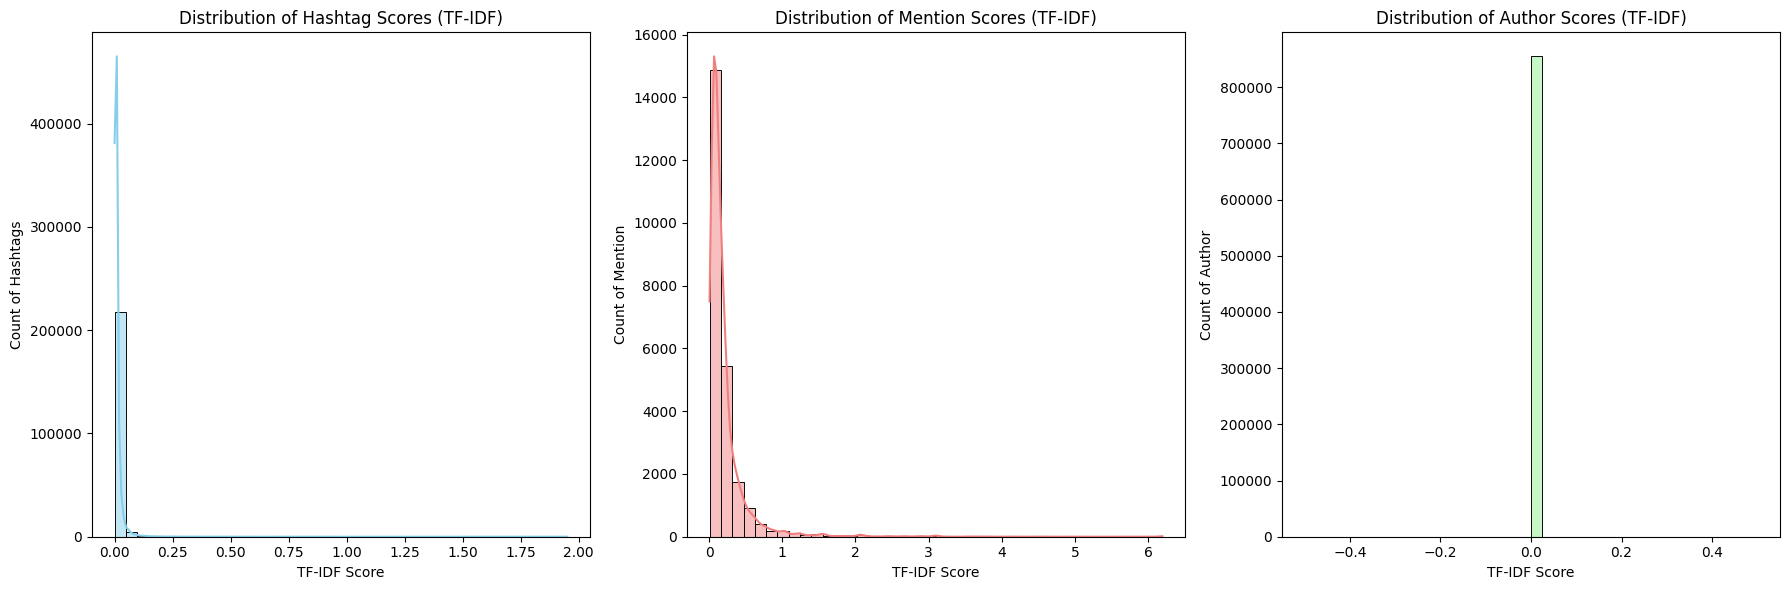

In [104]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Collecting Scores ---

all_hashtag_scores = get_all_tfidf_scores(hashtags_tfidf_dict)
all_mention_scores = get_all_tfidf_scores(mention_tfidf_dict)
all_author_scores = get_all_tfidf_scores(authors_tfidf_dict)

# --- Plotting the Histograms ---

plt.figure(figsize=(18, 6)) # Set the overall figure size

# Histogram for Hashtag Scores
plt.subplot(1, 3, 1) # 1 row, 3 columns, 1st plot
if all_hashtag_scores:
    sns.histplot(all_hashtag_scores, kde=True, bins=40, color='skyblue')
    plt.title('Distribution of Hashtag Scores (TF-IDF)') # Title changed to English
    plt.xlabel('TF-IDF Score') # X-axis label changed to English
    plt.ylabel('Count of Hashtags') # Y-axis label changed to English
    # plt.yscale('log')
    # plt.xscale('log')
else:
    plt.text(0.5, 0.5, 'No Hashtag Scores to display', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, fontsize=12)

# Histogram for Mention Scores
plt.subplot(1, 3, 2) # 1 row, 3 columns, 2nd plot
if all_mention_scores:
    sns.histplot(all_mention_scores, kde=True, bins=40, color='lightcoral')
    plt.title('Distribution of Mention Scores (TF-IDF)') # Title changed to English
    plt.xlabel('TF-IDF Score') # X-axis label changed to English
    plt.ylabel('Count of Mention') # Y-axis label changed to English
    # plt.yscale('log')
    # plt.xscale('log')
else:
    plt.text(0.5, 0.5, 'No Mention Scores to display', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, fontsize=12)

# Histogram for Author Scores
plt.subplot(1, 3, 3) # 1 row, 3 columns, 3rd plot
if all_author_scores:
    sns.histplot(all_author_scores, kde=True, bins=40, color='lightgreen')
    plt.title('Distribution of Author Scores (TF-IDF)') # Title changed to English
    plt.xlabel('TF-IDF Score') # X-axis label changed to English
    plt.ylabel('Count of Author') # Y-axis label changed to English
    # plt.yscale('log')
    # plt.xscale('log')
else:
    plt.text(0.5, 0.5, 'No Author Scores to display', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, fontsize=12)

plt.tight_layout()
plt.show()

# Min Max Scale

In [105]:
from collections import defaultdict

def min_max_normalize_by_topic(entity_tfidf_dict):
    """
    Normalize TF-IDF scores per topic using Min-Max normalization.
    Args:
        entity_tfidf_dict (dict): Nested dict {topic: {entity: score}}.
    Returns:
        dict: Nested dict {topic: {entity: normalized_score}}.
    """
    topic_to_stats = {}
    for topic, entity_scores in entity_tfidf_dict.items():
        scores = entity_scores.values()
        min_val = min(scores)
        max_val = max(scores)
        topic_to_stats[topic] = (min_val, max_val)

    norm_dict = defaultdict(lambda: defaultdict(float))
    for topic, entity_scores in entity_tfidf_dict.items():
        min_val, max_val = topic_to_stats[topic]
        for entity, score in entity_scores.items():
            if max_val - min_val == 0:
                norm_score = 0
            else:
                norm_score = (score - min_val) / (max_val - min_val)
            norm_dict[topic][entity] = norm_score

    return dict(norm_dict)

In [106]:
from itertools import islice

def print_nested_dict_preview(nested_dict, num_topics=2, num_entities=2):
    """
    Print a preview of a nested .
    Args:
        nested_dict (dict): The nested dictionary to print, dict: {topic: {entity: score}}.
        num_topics (int): number of topics to show.
        num_entities (int or None): Max number of entities per topic to show (None = show all).
    """
    for topic, entity_scores in islice(nested_dict.items(), num_topics):
        print(f"Topic: {topic}")
        for entity, score in islice(entity_scores.items(), num_entities):
            print(f"  {entity}: {score}")
        print()  # Blank line between topics
    print("--- End ---")
    print()

In [107]:
# Apply normalization to each entity type
norm_hashtag_scores = min_max_normalize_by_topic(hashtags_tfidf_dict)
norm_mention_scores = min_max_normalize_by_topic(mention_tfidf_dict)
norm_author_scores = min_max_normalize_by_topic(authors_tfidf_dict)


print("--- raw_hashtag_scores ---\n")
print_nested_dict_preview(hashtags_tfidf_dict)
print("--- norm_hashtag_scores ---\n")
print_nested_dict_preview(norm_hashtag_scores)

--- raw_hashtag_scores ---

Topic: 2
  #Uganda: 0.07282823658128308
  #News19: 0.013815719017426604

Topic: 770
  #Democratics: 0.008016265930001959
  #gop: 0.0019164106800505524

--- End ---

--- norm_hashtag_scores ---

Topic: 2
  #Uganda: 0.34860694173768036
  #News19: 0.06280166448947086

Topic: 770
  #Democratics: 0.0540495487123251
  #gop: 0.011707986187959579

--- End ---



In [108]:
import pandas as pd

def show_top_entities_before_after_normalization(original_dict, normalized_dict, topic_id, top_n=10):
    """
    Print top-N entities for a specific topic before and after normalization.

    Args:
        nested_dict (dict): {topic: {entity: score}}.
        original_dict (dict): {topic: {entity: raw_tfidf_score}}
        normalized_dict (dict): {topic: {entity: normalized_tfidf_score}}
        topic_id (int or str): the topic to filter by
        top_n (int): number of top entities to display
    """
    # Filter entries for the given topic
    data = []
    for entity in original_dict[topic_id].keys():
            data.append({
                'Entity': entity,
                'Raw TF-IDF': original_dict[topic_id][entity],
                'Normalized TF-IDF': normalized_dict[topic_id][entity]
            })

    df = pd.DataFrame(data)

    # Sort and select top N by raw TF-IDF
    top_raw = df.sort_values(by='Raw TF-IDF', ascending=False).head(top_n)
    print(f"\nTop {top_n} entities for topic {topic_id} — by **Raw TF-IDF**:\n")
    print(top_raw.to_string(index=False))

    # Sort and select top N by normalized TF-IDF
    top_norm = df.sort_values(by='Normalized TF-IDF', ascending=False).head(top_n)
    print(f"\nTop {top_n} entities for topic {topic_id} — by **Normalized TF-IDF**:\n")
    print(top_norm.to_string(index=False))


show_top_entities_before_after_normalization(
    hashtags_tfidf_dict,
    norm_hashtag_scores,
    topic_id=2,
    top_n=10
)


Top 10 entities for topic 2 — by **Raw TF-IDF**:

      Entity  Raw TF-IDF  Normalized TF-IDF
       #Mali    0.207327           1.000000
     #Uganda    0.072828           0.348607
        #RFI    0.061498           0.293734
     #French    0.050392           0.239948
#journalists    0.048810           0.232283
       #COYI    0.044259           0.210242
        #BPL    0.044259           0.210242
 #journalist    0.044137           0.209653
          #2    0.037010           0.175132
      #Marea    0.034611           0.163514

Top 10 entities for topic 2 — by **Normalized TF-IDF**:

      Entity  Raw TF-IDF  Normalized TF-IDF
       #Mali    0.207327           1.000000
     #Uganda    0.072828           0.348607
        #RFI    0.061498           0.293734
     #French    0.050392           0.239948
#journalists    0.048810           0.232283
       #COYI    0.044259           0.210242
        #BPL    0.044259           0.210242
 #journalist    0.044137           0.209653
          #

## Normalize the scores to ensure fair comparison across different entity types.

In [109]:
def compute_mean_score(scores):
    return np.mean(scores) if scores else 0

df['mean_hashtag_score'] = df['hashtag_scores'].apply(compute_mean_score)
# df['mean_url_score'] = df['url_scores'].apply(compute_mean_score)
df['mean_mention_score'] = df['mention_scores'].apply(compute_mean_score)
df['mean_author_score'] = df['author_score'].apply(compute_mean_score)

df.head()

,c_post_id,title,content,date,topic,author,hashtags,user_mentions,hashtag_scores,mention_scores,post_topic_tfidf,author_score,mean_hashtag_score,mean_mention_score,mean_author_score
0,00ef3764-f159-3166-b3e3-8b1147aed472,2 French journalists killed in Mali officials say,"RT @ hrw: # Uganda: 2 newspapers, 2 radio stat...",2013-05-21 10:27:02,2,[karmel80],[#Uganda],[],[0.07282823658128308],[],0,0.0,0.072828,0,0
1,01062bf4-590c-306d-b194-809d4c12b8b0,2 French journalists killed in Mali officials say,Officials: 2 French journalists killed in Mali...,2013-11-03 00:49:32,2,[MynameRillo],[],[],[],[],0,0.0,0.000000,0,0
2,0153a78a-de08-35ea-b9e2-d717e9b34ae0,2 French journalists killed in Mali officials say,DR (Danish Radio) tells the story of state-own...,2013-01-13 22:31:18,2,[JakobDrud],[],[],[],[],0,0.0,0.000000,0,0
3,02803736-bdab-3ff9-b5f6-933492f3b732,2 French journalists killed in Mali officials say,"Newspapers: Journalist / Regional Journalist, ...",2013-06-26 20:42:50,2,[uk_radio],[],[],[],[],0,0.0,0.000000,0,0
4,02bae70c-0075-3954-8fe0-24f62d068286,2 French journalists killed in Mali officials say,[WOI] Officials: 2 French journalists killed i...,2013-11-02 21:33:56,2,[DesMoinesNews],[],[],[],[],0,0.0,0.000000,0,0


In [110]:
df['min_max_post_score'] = (
    df['mean_hashtag_score'] +
    # df['mean_url_score'] +
    df['mean_mention_score'] +
    df['mean_author_score']
)

df.head()

,c_post_id,title,content,date,topic,author,hashtags,user_mentions,hashtag_scores,mention_scores,post_topic_tfidf,author_score,mean_hashtag_score,mean_mention_score,mean_author_score,min_max_post_score
0,00ef3764-f159-3166-b3e3-8b1147aed472,2 French journalists killed in Mali officials say,"RT @ hrw: # Uganda: 2 newspapers, 2 radio stat...",2013-05-21 10:27:02,2,[karmel80],[#Uganda],[],[0.07282823658128308],[],0,0.0,0.072828,0,0,0.072828
1,01062bf4-590c-306d-b194-809d4c12b8b0,2 French journalists killed in Mali officials say,Officials: 2 French journalists killed in Mali...,2013-11-03 00:49:32,2,[MynameRillo],[],[],[],[],0,0.0,0.000000,0,0,0.000000
2,0153a78a-de08-35ea-b9e2-d717e9b34ae0,2 French journalists killed in Mali officials say,DR (Danish Radio) tells the story of state-own...,2013-01-13 22:31:18,2,[JakobDrud],[],[],[],[],0,0.0,0.000000,0,0,0.000000
3,02803736-bdab-3ff9-b5f6-933492f3b732,2 French journalists killed in Mali officials say,"Newspapers: Journalist / Regional Journalist, ...",2013-06-26 20:42:50,2,[uk_radio],[],[],[],[],0,0.0,0.000000,0,0,0.000000
4,02bae70c-0075-3954-8fe0-24f62d068286,2 French journalists killed in Mali officials say,[WOI] Officials: 2 French journalists killed i...,2013-11-02 21:33:56,2,[DesMoinesNews],[],[],[],[],0,0.0,0.000000,0,0,0.000000


In [111]:
sorted_posts = df.sort_values(by=['topic', 'min_max_post_score'], ascending=[True, False])

In [112]:
num_topics = sorted_posts['topic'].unique()

for topic in num_topics:
    print(f"\nTop 5 Posts for Topic {topic}:")
    top_posts = sorted_posts[sorted_posts['topic'] == topic].head(5)
    for idx, row in top_posts.iterrows():
        print(f"Post ID: {row['c_post_id']}, Key Post Score: {row['min_max_post_score']:.4f}")
        print(f"Content: {row['content']}")
        print(f"Hashtags: {row['hashtags']}")
        # print(f"URL Scores: {row['url_scores']}")
        print(f"Mention Scores: {row['mention_scores']}")
        print(f"Author Score: {row['author_score']}")
        print()


Streaming output truncated to the last 5000 lines.
Author Score: 0.0

Post ID: 0e5544f8-70e0-32d8-94aa-163f471ce5a1, Key Post Score: 0.3370
Content: @ Harry_Styles Hi !We are from israel you are so perfect in SOML pls take a second to follow me and my sis @may_melech123 # StoryOfMyLife 172
Hashtags: ['#StoryOfMyLife']
Mention Scores: []
Author Score: 0.0


Top 5 Posts for Topic 842:
Post ID: 24d43c42-ed0d-32b3-8556-b7b53dfb7251, Key Post Score: 0.1315
Content: Someday telemarketing will be a crime punishable by the death penalty. On that day, I'll find my dream job. # Executioner
Hashtags: ['#Executioner']
Mention Scores: []
Author Score: 0.0

Post ID: 42d21922-960b-3394-a2de-0ad0db47f02e, Key Post Score: 0.1315
Content: @ pheebsss @vickyywadee If the death penalty does ever come to this country again, it looks like Phoebe will be getting a job # Executioner
Hashtags: ['#Executioner']
Mention Scores: []
Author Score: 0.0

Post ID: ce00b39c-ebfd-358d-8626-ee2dc0880cdf, Key Post Score: 0